In [59]:
# Preparing pathing
from titanic_ml import paths
import matplotlib.pyplot as plt
import pandas as pd
from titanic_ml.common.data.eda import quick_description, summarize_categorical_column, summarize_numerical_column, deep_describe


In [60]:
from titanic_ml.data import load_train_data

df = load_train_data()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [61]:
from titanic_ml.common.data.eda import quick_description
TARGET = "Survived"

# EDA: Exploratory Data Analysis
quick_description(df)

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
------------------------
DataFrame shape: (891, 12)
------------------------
DataFrame columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
---------------

In [62]:
# Length of string columns
length = df['Embarked'].str.len().describe()
print(f"Length of 'Embarked':\n{length}")

'''
This reveals:

free text
codes
IDs
malformed entries

Example:

all length 2 → state codes
all length 36 → UUIDs
huge variance → real text

Very powerful for schema discovery.
'''


# Cardinality: number of unique values / total rows
cardinality = df['Embarked'].nunique(dropna=True) / len(df['Embarked'])
print(f"Cardinality of 'Embarked': {cardinality:.2%}")

# Ratio	Meaning
'''
Very low = categorical
Medium = mixed
Very high = ID-like/free text

Example:

gender → 0.00002
country → 0.01
customer_id → 1.0

This immediately reveals:

IDs
UUIDs
text fields
columns unsuitable for one-hot encoding
'''

# Dominance Ratio
top_freq = df['Embarked'].value_counts(dropna=False, normalize=True).iloc[0]
print(f"Dominance Ratio of 'Embarked': {top_freq:.2%}")

'''
Dominance Ratio	Meaning
Very low = no dominant category
Medium = some dominance
Very high = one category dominates

useful for detecting useless columns.

If:

one value = 99%
column may be useless

Example:
"ACTIVE" repeated everywhere
'''

print()
print()
# Memory usage
df.memory_usage(deep=True)
print(f"Total memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Column health summary
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_%': df.isna().mean() * 100,
    'unique': df.nunique(),
    'cardinality_%': df.nunique() / len(df) * 100,
    'top_value': df.apply(lambda s: s.value_counts(dropna=False).idxmax()),
    'dominance_%': df.apply(lambda s: s.value_counts(dropna=False, normalize=True).iloc[0] * 100),
    'bottom_value': df.apply(lambda s: s.value_counts(dropna=False).idxmin()),
})

summary = summary.sort_values(
    by='missing_%',
    ascending=False
)

print(summary)


Length of 'Embarked':
count    889.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: Embarked, dtype: float64
Cardinality of 'Embarked': 0.34%
Dominance Ratio of 'Embarked': 72.28%


Total memory usage: 315.03 KB
               dtype  missing_%  unique  cardinality_%  \
Cabin         object  77.104377     147      16.498316   
Age          float64  19.865320      88       9.876543   
Embarked      object   0.224467       3       0.336700   
PassengerId    int64   0.000000     891     100.000000   
Survived       int64   0.000000       2       0.224467   
Pclass         int64   0.000000       3       0.336700   
Name          object   0.000000     891     100.000000   
Sex           object   0.000000       2       0.224467   
SibSp          int64   0.000000       7       0.785634   
Parch          int64   0.000000       7       0.785634   
Ticket        object   0.000000     681      76.430976   
Fare         float64   0.000

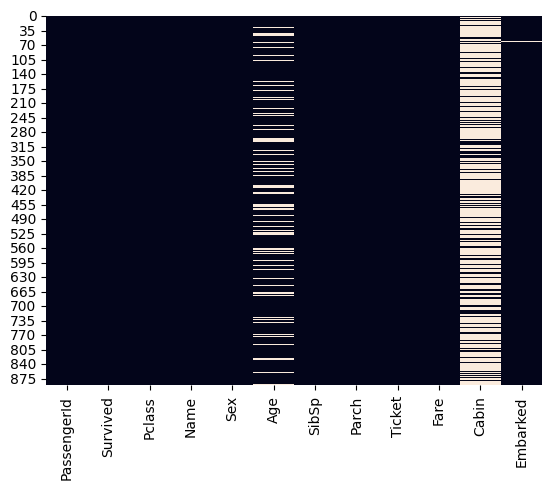

In [63]:
import seaborn as sns
# Missing Values Heatmap
sns.heatmap(df.isna(), cbar=False)

'''
This immediately shows:
missingness structure
grouped missing values
data pipeline problems
'''
plt.show()

<Axes: >

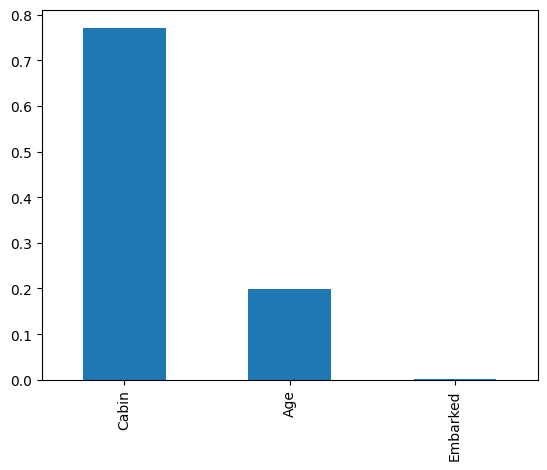

In [64]:
# Missing Percentage Barplot
missing = df.isna().mean().sort_values(ascending=False)

missing[missing > 0].plot.bar()

<Axes: >

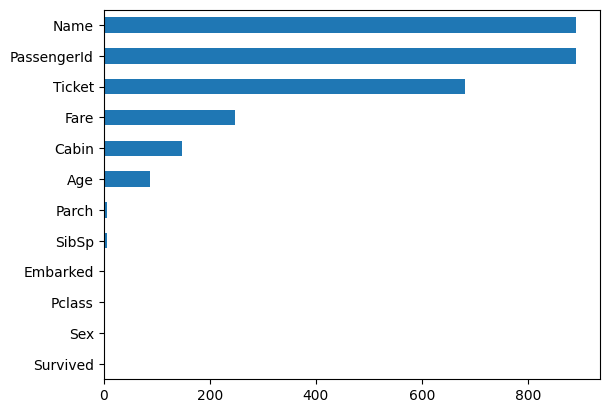

In [65]:
# cardinality barplot
df.nunique().sort_values().plot.barh()

In [66]:
def summarize_categorical_column(series, max_display=20):
    # Count frequencies including NaN
    counts = series.value_counts(dropna=False)

    # Percentages
    percents = (
        series.value_counts(dropna=False, normalize=True) * 100
    ).round(2)

    # Build summary table
    summary = pd.DataFrame({
        'count': counts,
        'percent': percents
    })

    # Renaming NA/None to 'MISSING' for better readability
    summary = summary.rename(index={pd.NA: 'MISSING', None: 'MISSING'})

    # If small enough, show everything
    if len(summary) <= max_display:
        return summary

    # Otherwise show top/bottom
    top_n = max_display // 2

    truncated = pd.concat([
        summary.head(top_n),
        pd.DataFrame(
            {'count': ['...'], 'percent': ['...']},
            index=['...']
        ),
        summary.tail(top_n)
    ])

    return truncated

def summarize_numerical_column(df):
    return df.describe(include=['number'])

def deep_describe(df):

    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    numerical_cols = df.select_dtypes(include=['number']).columns

    print('Categorical columns summary:')
    for col in categorical_cols:
        print(f'\n=== {col} ===')
        print(summarize_categorical_column(df[col]))
    
    print('Numerical columns summary:')
    for col in numerical_cols:
        print(f'\n=== {col} ===')
        print(summarize_numerical_column(df[col]))

def summarize_dataframe(df):
    summary = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_%': df.isna().mean() * 100,
    'unique': df.nunique(),
    'cardinality_%': df.nunique() / len(df) * 100,
    'top_value': df.apply(lambda s: s.value_counts(dropna=False).idxmax()),
    'dominance_%': df.apply(lambda s: s.value_counts(dropna=False, normalize=True).iloc[0] * 100),
    'bottom_value': df.apply(lambda s: s.value_counts(dropna=False).idxmin()),
    })

    summary = summary.sort_values(
        by='missing_%',
        ascending=False
    )

    print(summary)

summarize_dataframe(df)
deep_describe(df)

               dtype  missing_%  unique  cardinality_%  \
Cabin         object  77.104377     147      16.498316   
Age          float64  19.865320      88       9.876543   
Embarked      object   0.224467       3       0.336700   
PassengerId    int64   0.000000     891     100.000000   
Survived       int64   0.000000       2       0.224467   
Pclass         int64   0.000000       3       0.336700   
Name          object   0.000000     891     100.000000   
Sex           object   0.000000       2       0.224467   
SibSp          int64   0.000000       7       0.785634   
Parch          int64   0.000000       7       0.785634   
Ticket        object   0.000000     681      76.430976   
Fare         float64   0.000000     248      27.833895   

                           top_value  dominance_%             bottom_value  
Cabin                            NaN    77.104377                      A23  
Age                              NaN    19.865320                     34.5  
Embarked      

In [67]:
import pandas as pd


def format_missing_index(index):
    return ["MISSING" if pd.isna(idx) else idx for idx in index]


def summarize_categorical_column(series, max_display=20):
    counts = series.value_counts(dropna=False)
    percents = (series.value_counts(dropna=False, normalize=True) * 100).round(2)

    summary = pd.DataFrame({
        "count": counts,
        "percent": percents,
    })

    summary.index = format_missing_index(summary.index)

    if len(summary) <= max_display:
        return summary

    top_n = max_display // 2

    truncated = pd.concat([
        summary.head(top_n),
        pd.DataFrame(
            {"count": ["..."], "percent": ["..."]},
            index=["..."],
        ),
        summary.tail(top_n),
    ])

    return truncated


def summarize_numerical_column(series):
    summary = series.describe()

    extra = pd.Series({
        "missing_count": series.isna().sum(),
        "missing_%": round(series.isna().mean() * 100, 2),
        "skew": series.skew(),
        "kurtosis": series.kurtosis(),
    })

    return pd.concat([summary, extra])


def safe_top_value(series):
    counts = series.value_counts(dropna=False)
    if counts.empty:
        return None
    value = counts.index[0]
    return "MISSING" if pd.isna(value) else value


def safe_bottom_value(series):
    counts = series.value_counts(dropna=False)
    if counts.empty:
        return None
    value = counts.index[-1]
    return "MISSING" if pd.isna(value) else value


def summarize_dataframe(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null_count": df.notna().sum(),
        "missing_count": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=False),
        "cardinality_%": (df.nunique(dropna=False) / len(df) * 100).round(2),
        "top_value": df.apply(safe_top_value),
        "dominance_%": df.apply(
            lambda s: round(s.value_counts(dropna=False, normalize=True).iloc[0] * 100, 2)
            if not s.empty else None
        ),
        "bottom_value": df.apply(safe_bottom_value),
    })

    return summary.sort_values(by="missing_%", ascending=False)


def display_dataframe_description(df, max_display=20):
    categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns
    numerical_cols = df.select_dtypes(include=["number"]).columns

    print("DataFrame Summary:")
    print(summarize_dataframe(df))
    print("="*60)
    print("Categorical columns summary:")
    for col in categorical_cols:
        print(f"\n=== {col} ===")
        print(summarize_categorical_column(df[col], max_display=max_display))
    print("="*60)
    print("\nNumerical columns summary:")
    for col in numerical_cols:
        print(f"\n=== {col} ===")
        print(summarize_numerical_column(df[col]))

In [68]:
display_dataframe_description(df)

DataFrame Summary:
               dtype  non_null_count  missing_count  missing_%  unique  \
Cabin         object             204            687      77.10     148   
Age          float64             714            177      19.87      89   
Embarked      object             889              2       0.22       4   
PassengerId    int64             891              0       0.00     891   
Survived       int64             891              0       0.00       2   
Pclass         int64             891              0       0.00       3   
Name          object             891              0       0.00     891   
Sex           object             891              0       0.00       2   
SibSp          int64             891              0       0.00       7   
Parch          int64             891              0       0.00       7   
Ticket        object             891              0       0.00     681   
Fare         float64             891              0       0.00     248   

             cardi

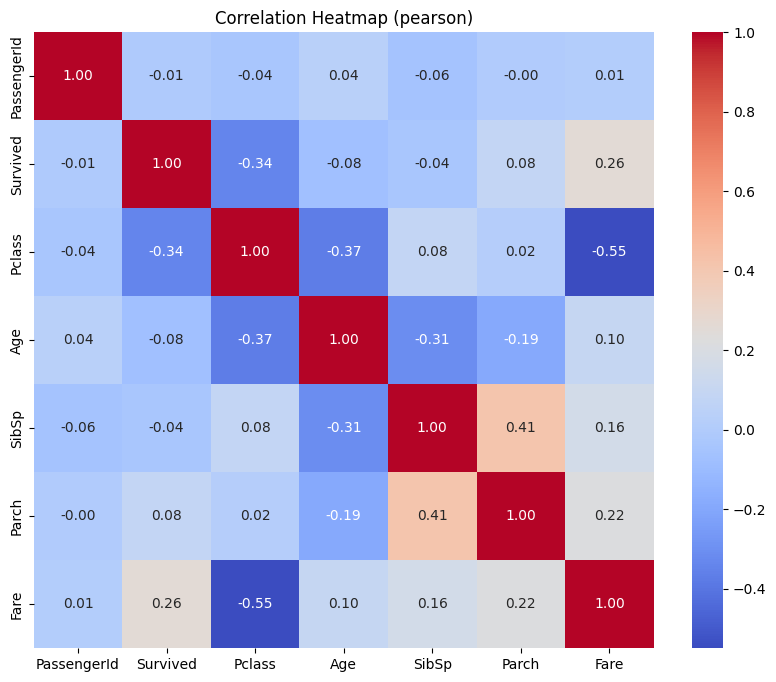


Absolute correlation of features with target 'Survived':
Pclass        -0.338481
Fare           0.257307
Parch          0.081629
Age           -0.077221
SibSp         -0.035322
PassengerId   -0.005007
Name: Survived, dtype: float64


In [69]:
def correlation_analysis(
    df,
    method="pearson",
    target=None,
):
    numerical_df = df.select_dtypes(include=['number'])
    Cor = numerical_df.corr(method=method)
    plt.figure(figsize=(10, 8))
    sns.heatmap(Cor, annot=True, cmap='coolwarm',fmt=".2f")
    plt.title(f"Correlation Heatmap ({method})")
    plt.show()

    if target is not None and target in Cor.columns:
        target_corr = (
            Cor[target]
            .drop(target)
            .sort_values(key=lambda s: s.abs(), ascending=False)
            )
        print(f"\nAbsolute correlation of features with target '{target}':")
        print(target_corr)

correlation_analysis(df, method="pearson", target=TARGET)

In [70]:
def summarize_duplicates(df):
    duplicate_count = df.duplicated().sum()

    return pd.Series({
        "duplicate_rows": duplicate_count,
        "duplicate_%": round(duplicate_count / len(df) * 100, 2),
    })

duplicate_summary = summarize_duplicates(df)
print("\nDuplicate Rows Summary:")
print(duplicate_summary)


Duplicate Rows Summary:
duplicate_rows    0.0
duplicate_%       0.0
dtype: float64


In [71]:
def summarize_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (series < lower) | (series > upper)

    return pd.Series({
        "outlier_count": mask.sum(),
        "outlier_%": round(mask.mean() * 100, 2),
    })

numerical_df = df.select_dtypes(include=['number'])
outlier_summary = numerical_df.apply(summarize_outliers)
print("\nOutliers Summary:")
print(outlier_summary)


Outliers Summary:
               PassengerId  Survived  Pclass    Age  SibSp   Parch    Fare
outlier_count          0.0       0.0     0.0  11.00  46.00  213.00  116.00
outlier_%              0.0       0.0     0.0   1.23   5.16   23.91   13.02


In [72]:
def classify_skew(skew):
    skew = abs(skew)

    if skew < 0.5:
        return "low"

    if skew < 1:
        return "moderate"

    return "high"

In [73]:
def categorical_vs_target(df, feature, target):
    summary = pd.crosstab(
        df[feature],
        df[target],
        normalize="index"
    ) * 100

    return summary

for cat in df.select_dtypes(include=["object", "category", "bool"]).columns:
    print(f"\n=== {cat} vs {TARGET} ===")
    categorical_summary = categorical_vs_target(df, feature=cat, target=TARGET)
    print("\nCategorical vs Target Summary:")
    print(categorical_summary)



=== Name vs Survived ===

Categorical vs Target Summary:
Survived                                   0      1
Name                                               
Abbing, Mr. Anthony                    100.0    0.0
Abbott, Mr. Rossmore Edward            100.0    0.0
Abbott, Mrs. Stanton (Rosa Hunt)         0.0  100.0
Abelson, Mr. Samuel                    100.0    0.0
Abelson, Mrs. Samuel (Hannah Wizosky)    0.0  100.0
...                                      ...    ...
de Mulder, Mr. Theodore                  0.0  100.0
de Pelsmaeker, Mr. Alfons              100.0    0.0
del Carlo, Mr. Sebastiano              100.0    0.0
van Billiard, Mr. Austin Blyler        100.0    0.0
van Melkebeke, Mr. Philemon            100.0    0.0

[891 rows x 2 columns]

=== Sex vs Survived ===

Categorical vs Target Summary:
Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815

=== Ticket vs Survived ===

Categorical vs Target Summary:
S

In [ ]:
import pandas as pd


def format_missing_index(index):
    return ["MISSING" if pd.isna(idx) else idx for idx in index]


def safe_top_value(series):
    counts = series.value_counts(dropna=False)
    if counts.empty:
        return None
    value = counts.index[0]
    return "MISSING" if pd.isna(value) else value


def safe_bottom_value(series):
    counts = series.value_counts(dropna=False)
    if counts.empty:
        return None
    value = counts.index[-1]
    return "MISSING" if pd.isna(value) else value


def summarize_dataframe(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null_count": df.notna().sum(),
        "missing_count": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=False),
        "cardinality_%": (df.nunique(dropna=False) / len(df) * 100).round(2),
        "top_value": df.apply(safe_top_value),
        "dominance_%": df.apply(
            lambda s: round(s.value_counts(dropna=False, normalize=True).iloc[0] * 100, 2)
            if not s.empty else None
        ),
        "bottom_value": df.apply(safe_bottom_value),
    })

    return summary.sort_values(by="missing_%", ascending=False)

def summarize_dataframe_health(df):
    rows_with_missing = df.isna().any(axis=1).sum()
    duplicate_rows = df.duplicated().sum()

    return pd.Series({
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": duplicate_rows,
        "duplicate_%": round(duplicate_rows / len(df) * 100, 2),
        "rows_with_missing": rows_with_missing,
        "rows_with_missing_%": round(rows_with_missing / len(df) * 100, 2),
        "total_missing_values": df.isna().sum().sum(),
    })

def summarize_categorical_column(df, feature, target=None, max_display=20):
    feature_series = df[feature].fillna("MISSING")

    counts = feature_series.value_counts(dropna=False)
    percents = (feature_series.value_counts(dropna=False, normalize=True) * 100).round(2)

    summary = pd.DataFrame({
        "count": counts,
        "percent": percents,
    })

    if target is not None:
        target_summary = pd.crosstab(
            feature_series,
            df[target],
            normalize="index"
        ).round(4) * 100

        target_summary.columns = [
            f"{target}_{col}_%" for col in target_summary.columns
        ]

        summary = summary.join(target_summary)

    if len(summary) <= max_display:
        return summary

    top_n = max_display // 2

    separator = pd.DataFrame(
        {col: ["..."] for col in summary.columns},
        index=["..."]
    )

    return pd.concat([
        summary.head(top_n),
        separator,
        summary.tail(top_n),
    ])

def classify_skew(skew):
    skew = abs(skew)

    if skew < 0.5:
        return ("low skew", skew)

    if skew < 1:
        return ("moderate skew", skew)

    return ("high skew", skew)

def classify_kurtosis(kurtosis):
    kurtosis = abs(kurtosis)

    if kurtosis < 0.5:
        return ("low kurtosis", kurtosis)

    if kurtosis < 1:
        return ("moderate kurtosis", kurtosis)

    return ("high kurtosis", kurtosis)




def summarize_numerical_column(series):
    summary = series.describe()

    clean = series.dropna()

    if clean.empty:
        extra = pd.Series({
            "missing_count": series.isna().sum(),
            "missing_%": round(series.isna().mean() * 100, 2),
            "outlier_count": 0,
            "outlier_%": 0,
            "skew": None,
            "kurtosis": None,
        })
        return pd.concat([summary, extra])

    q1 = clean.quantile(0.25)
    q3 = clean.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (clean < lower) | (clean > upper)

    extra = pd.Series({
        "missing_count": series.isna().sum(),
        "missing_%": round(series.isna().mean() * 100, 2),
        "outlier_count": mask.sum(),
        "outlier_%": round(mask.mean() * 100, 2),
        "skew": clean.skew(),
        "kurtosis": clean.kurtosis(),
    })

    return pd.concat([summary, extra])

def display_dataframe_description(df, max_display=20, target=None):
    categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns
    numerical_cols = df.select_dtypes(include=["number"]).columns

    numeric_summary = pd.DataFrame({
        col: summarize_numerical_column(df[col])
        for col in numerical_cols
    }).T

    categorical_summaries = {
        col: summarize_categorical_column(df, col, target="Survived")
        for col in categorical_cols
    }

    print("DataFrame Summary:")
    print(summarize_dataframe(df))
    print("="*60)
    print('Dataframe Health')
    print(summarize_dataframe_health(df))
    print("="*60)
    print("Categorical columns summary:")
    for col in categorical_cols:
        print(f"\n=== {col} ===")
        print(summarize_categorical_column(df, col, max_display=max_display, target=target))
    print("="*60)
    print("\nNumerical columns summary:")
    print(numeric_summary)

In [75]:
display_dataframe_description(df, target=TARGET)

DataFrame Summary:
               dtype  non_null_count  missing_count  missing_%  unique  \
Cabin         object             204            687      77.10     148   
Age          float64             714            177      19.87      89   
Embarked      object             889              2       0.22       4   
PassengerId    int64             891              0       0.00     891   
Survived       int64             891              0       0.00       2   
Pclass         int64             891              0       0.00       3   
Name          object             891              0       0.00     891   
Sex           object             891              0       0.00       2   
SibSp          int64             891              0       0.00       7   
Parch          int64             891              0       0.00       7   
Ticket        object             891              0       0.00     681   
Fare         float64             891              0       0.00     248   

             cardi

In [ ]:
def classify_dominance(dominance):
    dominance = abs(dominance)

    if dominance >= 0.95:
        return ("Column is almost constant", dominance)

    if dominance == 1:
        return ("Column is constant", dominance)
    
    if dominance >= 0.3:
        return ("Some dominance", dominance)

    return ("No dominance", dominance)



Duplicate Rows Summary:
duplicate_rows    0.0
duplicate_%       0.0
dtype: float64


In [ ]:
def classify_cardinality(cardinality):
    cardinality = abs(cardinality)

    if cardinality >= 0.95:
        return ("Column is almost constant", cardinality)

    if cardinality == 1:
        return ("Column is constant", cardinality)
    
    if cardinality >= 0.3:
        return ("Some dominance", cardinality)

    return ("No dominance", cardinality)


Very low = categorical
Medium = mixed
Very high = ID-like/free text

In [85]:
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

categorical_summaries = {
    col: summarize_categorical_column(df, col, target="Survived")
    for col in categorical_cols
}

for col, values in categorical_summaries.items():
    print(col)
    print(values)
    print('='*60)

Name
                                                count percent Survived_0_%  \
Braund, Mr. Owen Harris                             1    0.11        100.0   
Boulos, Mr. Hanna                                   1    0.11        100.0   
Frolicher-Stehli, Mr. Maxmillian                    1    0.11          0.0   
Gilinski, Mr. Eliezer                               1    0.11        100.0   
Murdlin, Mr. Joseph                                 1    0.11        100.0   
Rintamaki, Mr. Matti                                1    0.11        100.0   
Stephenson, Mrs. Walter Bertram (Martha Eustis)     1    0.11          0.0   
Elsbury, Mr. William James                          1    0.11        100.0   
Bourke, Miss. Mary                                  1    0.11        100.0   
Chapman, Mr. John Henry                             1    0.11        100.0   
...                                               ...     ...          ...   
Lewy, Mr. Ervin G                                   1    0.

In [ ]:
def classify_skew(skew):
    skew = abs(skew)

    if skew < 0.5:
        return ("low skew", skew)

    if skew < 1:
        return ("moderate skew", skew)

    return ("high skew", skew)


low f('skew')
